# Step 1: Explore the Battery Data 🔋

**Goal:** Understand what's inside `battery00.csv` before we do any modelling.

**Dataset:** NASA Accelerated Life Test (ALT) battery data
- 18650 Li-ion cells, 2 cells connected in series (pack)
- Contains charge cycles, discharge cycles, and rest periods
- We will use this data to build a SOC (State of Charge) estimator

**Questions to answer:**
1. How big is the dataset?
2. What columns do we have and what do they mean?
3. What do the voltage and current patterns look like?
4. Which data is the "reference discharge" we need?

## 1.1 Load the Data

First, let's import our libraries and load the CSV file.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the CSV file
df = pd.read_csv("../data/nasa_alt/battery00.csv")

# How big is the data?
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumn names: {df.columns.tolist()}")

Rows: 1,101,244
Columns: 10

Column names: ['start_time', 'time', 'mode', 'voltage_charger', 'temperature_battery', 'voltage_load', 'current_load', 'temperature_mosfet', 'temperature_resistor', 'mission_type']


In [2]:
# Look at the first 10 rows
df.head(10)

,start_time,time,mode,voltage_charger,temperature_battery,voltage_load,current_load,temperature_mosfet,temperature_resistor,mission_type
0,2022-07-19 11:10:00,0.000,0.0,0.000,0.000,NaN,NaN,NaN,NaN,NaN
1,2022-07-19 11:10:00,1.894,0.0,8.341,23.059,NaN,NaN,NaN,NaN,NaN
2,2022-07-19 11:10:00,2.814,0.0,8.340,23.059,NaN,NaN,NaN,NaN,NaN
3,2022-07-19 11:10:00,3.734,0.0,8.341,23.063,NaN,NaN,NaN,NaN,NaN
4,2022-07-19 11:10:00,4.654,0.0,8.341,23.063,NaN,NaN,NaN,NaN,NaN
5,2022-07-19 11:10:00,5.573,0.0,8.341,23.059,NaN,NaN,NaN,NaN,NaN
6,2022-07-19 11:10:00,6.494,0.0,8.341,23.063,NaN,NaN,NaN,NaN,NaN
7,2022-07-19 11:10:00,7.413,0.0,8.341,23.059,NaN,NaN,NaN,NaN,NaN
8,2022-07-19 11:10:00,8.333,0.0,8.341,23.059,NaN,NaN,NaN,NaN,NaN
9,2022-07-19 11:10:00,9.254,0.0,8.341,23.059,NaN,NaN,NaN,NaN,NaN


## 1.2 Understand the Columns

| Column | What it means |
|--------|--------------|
| `start_time` | Timestamp when the test started |
| `time` | Time in **seconds** since start |
| `mode` | **-1** = discharge, **0** = rest/idle, **1** = charge |
| `voltage_charger` | Voltage measured at charger side (always available) |
| `voltage_load` | Voltage measured at load side (only during discharge) |
| `current_load` | Current flowing through load (only during discharge) |
| `temperature_battery` | Battery temperature (°C) |
| `temperature_mosfet` | MOSFET temperature (°C) |
| `temperature_resistor` | Resistor temperature (°C) |
| `mission_type` | **0** = reference cycle, **1** = mission/aging cycle |

**Key takeaways:**
- `mode = -1` → battery is **discharging** (this is what we care about!)
- `mission_type = 0` → **reference discharge** (constant current ~2.5A — our main data)
- `voltage_load` and `current_load` are **NaN during rest and charge** (only measured during discharge)

In [3]:
# Check data types and see how many non-null values each column has
print("Data types and non-null counts:")
print("=" * 50)
print(df.dtypes)
print(f"\nTotal rows: {len(df):,}")
print(f"\nNon-null counts:")
for col in df.columns:
    non_null = df[col].notna().sum()
    pct = non_null / len(df) * 100
    print(f"  {col:25s} {non_null:>10,} ({pct:.1f}%)")

Data types and non-null counts:
start_time               object
time                    float64
mode                    float64
voltage_charger         float64
temperature_battery     float64
voltage_load            float64
current_load            float64
temperature_mosfet      float64
temperature_resistor    float64
mission_type            float64
dtype: object

Total rows: 1,101,244

Non-null counts:
  start_time                 1,101,244 (100.0%)
  time                       1,101,244 (100.0%)
  mode                       1,101,244 (100.0%)
  voltage_charger            1,101,244 (100.0%)
  temperature_battery        1,101,244 (100.0%)
  voltage_load                 106,006 (9.6%)
  current_load                 106,006 (9.6%)
  temperature_mosfet           106,006 (9.6%)
  temperature_resistor         106,006 (9.6%)
  mission_type                 106,006 (9.6%)


In [4]:
# Quick statistics
df.describe()

,time,mode,voltage_charger,temperature_battery,voltage_load,current_load,temperature_mosfet,temperature_resistor,mission_type
count,1.101244e+06,1.101244e+06,1.101244e+06,1.101244e+06,106006.000000,106006.000000,106006.000000,106006.000000,106006.000000
mean,5.384530e+05,3.606294e-01,7.474418e+00,3.677118e+01,6.508119,12.800680,29.450786,28.692611,0.729581
std,3.113311e+05,6.504588e-01,1.026228e+00,1.642336e+01,0.705210,6.328622,3.174423,3.875901,0.444178
min,0.000000e+00,-1.000000e+00,-6.000000e-02,0.000000e+00,-0.027000,0.150000,18.220000,22.010000,0.000000
25%,2.691612e+05,0.000000e+00,6.944000e+00,2.523300e+01,6.067000,2.521000,25.190000,23.140000,0.000000
50%,5.371203e+05,0.000000e+00,7.761000e+00,3.241600e+01,6.450000,16.528084,31.060000,31.040000,1.000000
75%,8.080463e+05,1.000000e+00,8.226000e+00,3.914100e+01,6.880000,16.846305,31.940000,31.700000,1.000000
max,1.079483e+06,1.000000e+00,9.176000e+00,1.023080e+02,8.703000,19.391040,33.460000,35.160000,1.000000


## 1.3 Visualize the Full Dataset

Let's plot the voltage over the entire test to see the charge/discharge pattern.

**What to expect:** You'll see a repeating pattern — voltage goes UP (charging) then DOWN (discharging), like a zigzag.

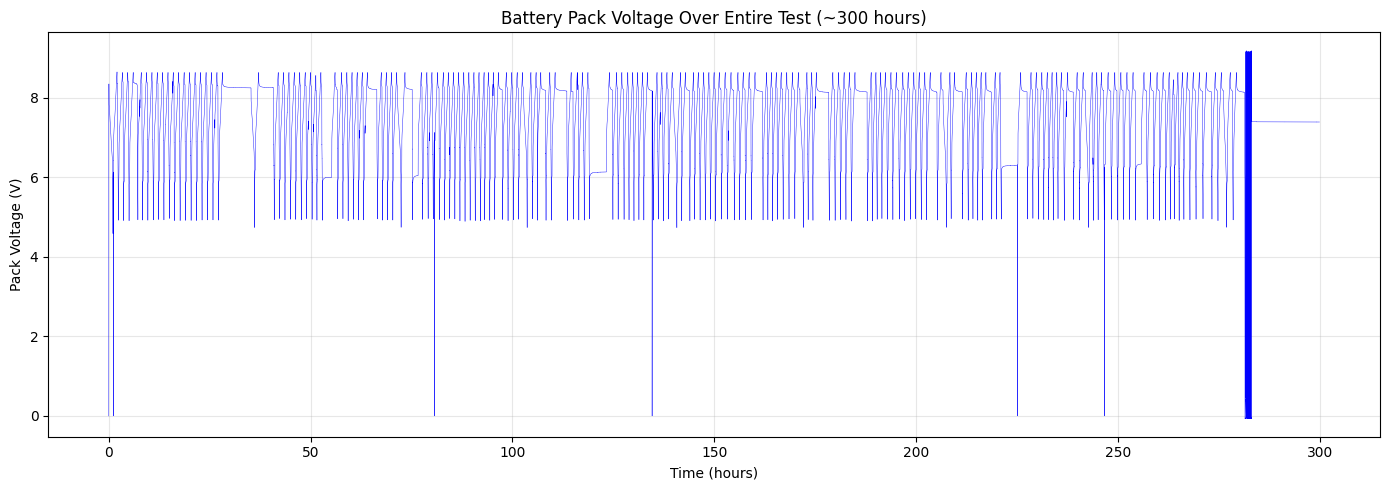

In [5]:
# Plot voltage over the entire test
plt.figure(figsize=(14, 5))
plt.plot(df['time'] / 3600, df['voltage_charger'], linewidth=0.3, color='blue')
plt.xlabel('Time (hours)')
plt.ylabel('Pack Voltage (V)')
plt.title('Battery Pack Voltage Over Entire Test (~300 hours)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 1.4 Understand the Modes

The `mode` column tells us what the battery is doing at each moment:
- **mode = 1** → Charging (voltage going UP)
- **mode = 0** → Resting (voltage stable, no current)
- **mode = -1** → Discharging (voltage going DOWN) ← **This is what we need!**

Let's count how much data we have for each mode:

In [6]:
# Count rows for each mode
mode_counts = df['mode'].value_counts().sort_index()
print("Mode counts:")
print("=" * 30)
for mode, count in mode_counts.items():
    mode_name = {-1: "Discharge", 0: "Rest/Idle", 1: "Charge"}
    print(f"  mode = {mode:>2.0f} ({mode_name.get(mode, '?'):>10s}): {count:>10,} rows")

# Also check mission_type
print(f"\nMission type counts:")
mt_counts = df['mission_type'].value_counts(dropna=False).sort_index()
for mt, count in mt_counts.items():
    label = "Reference cycle" if mt == 0 else ("Mission/aging cycle" if mt == 1 else "NaN (rest/charge)")
    print(f"  mission_type = {mt}: {count:>10,} rows  ({label})")

Mode counts:
  mode = -1 ( Discharge):    106,006 rows
  mode =  0 ( Rest/Idle):    492,091 rows
  mode =  1 (    Charge):    503,147 rows

Mission type counts:
  mission_type = 0.0:     28,666 rows  (Reference cycle)
  mission_type = 1.0:     77,340 rows  (Mission/aging cycle)
  mission_type = nan:    995,238 rows  (NaN (rest/charge))


## 1.5 Filter: Reference Discharge Only

For our project, we need **reference discharge cycles** — these are:
- `mode == -1` (discharging)
- `mission_type == 0` (reference, not aging)

These are constant-current discharges at ~2.5A that go from 100% → 0% SOC.
This is the clean data we'll use to model the battery.

In [7]:
# Filter reference discharge data
ref_discharge = df[(df['mode'] == -1) & (df['mission_type'] == 0)]

print(f"Reference discharge data: {len(ref_discharge):,} rows")
print(f"\nVoltage range (pack): {ref_discharge['voltage_load'].min():.3f} to {ref_discharge['voltage_load'].max():.3f} V")
print(f"Current range:         {ref_discharge['current_load'].min():.3f} to {ref_discharge['current_load'].max():.3f} A")
print(f"Time span:             {ref_discharge['time'].min():.0f} to {ref_discharge['time'].max():.0f} seconds")

Reference discharge data: 28,666 rows

Voltage range (pack): -0.026 to 8.397 V
Current range:         0.150 to 2.523 A
Time span:             301 to 996835 seconds


## 1.6 How Many Reference Discharge Cycles?

The reference discharges happen at different times during the test. Between each discharge, there's a long gap (charging + resting + aging cycles). We can find individual cycles by looking for **time gaps > 100 seconds** between consecutive rows.

In [8]:
# Find where big time gaps occur (= boundaries between cycles)
time_diff = ref_discharge['time'].diff()        # Time between consecutive rows
gap_indices = time_diff[time_diff > 100].index   # Gaps bigger than 100 seconds

print(f"Found {len(gap_indices)} gaps → means {len(gap_indices) + 1} discharge cycles")

# Split into individual cycles
cycles = []
start_idx = ref_discharge.index[0]

for gap_idx in gap_indices:
    cycle = ref_discharge.loc[start_idx:gap_idx - 1].copy()
    cycles.append(cycle)
    start_idx = gap_idx

# Don't forget the last cycle
cycles.append(ref_discharge.loc[start_idx:].copy())

# Show info about each cycle
print(f"\nCycle details:")
print(f"{'Cycle':>5}  {'Rows':>6}  {'Duration (s)':>12}  {'V_start':>8}  {'V_end':>8}  {'Avg Current':>12}")
print("-" * 65)
for i, cycle in enumerate(cycles):
    duration = cycle['time'].iloc[-1] - cycle['time'].iloc[0]
    v_start = cycle['voltage_load'].iloc[0]
    v_end = cycle['voltage_load'].iloc[-1]
    avg_i = cycle['current_load'].mean()
    print(f"{i+1:>5}  {len(cycle):>6}  {duration:>12.0f}  {v_start:>8.3f}  {v_end:>8.3f}  {avg_i:>10.3f} A")

Found 8 gaps → means 9 discharge cycles

Cycle details:
Cycle    Rows  Duration (s)   V_start     V_end   Avg Current
-----------------------------------------------------------------
    1    3674          3503    -0.026     4.814       2.520 A
    2    3534          3355    -0.026     4.905       2.519 A
    3    3277          3277    -0.026     4.911       2.519 A
    4    3189          3198    -0.026     4.904       2.520 A
    5    3216          3117    -0.026     4.901       2.520 A
    6    2997          3044    -0.026     4.907       2.519 A
    7    3097          2979    -0.026     4.907       2.520 A
    8    2959          2918    -0.026     4.906       2.519 A
    9    2723          2856    -0.026     4.909       2.519 A


## 1.7 Plot the First (BoL) Reference Discharge

**BoL = Beginning of Life** — the first cycle, when the battery is brand new.

This is the cycle we'll use for everything: OCV-SOC curve, ECM parameters, and EKF testing.

Let's plot its voltage and current:

In [9]:
# Get the first (BoL) discharge cycle
bol = cycles[0].copy()

# Make time start from 0 for this cycle
bol['time_relative'] = bol['time'] - bol['time'].iloc[0]

# Calculate per-cell voltage (2 cells in series → divide by 2)
bol['voltage_per_cell'] = bol['voltage_load'] / 2.0

# Calculate capacity discharged
duration = bol['time_relative'].max()
avg_current = bol['current_load'].mean()
capacity_ah = avg_current * duration / 3600

print("=== BoL Reference Discharge ===")
print(f"Duration:      {duration:.0f} seconds ({duration/60:.1f} minutes)")
print(f"Avg current:   {avg_current:.3f} A")
print(f"Capacity:      {capacity_ah:.3f} Ah")
print(f"Pack voltage:  {bol['voltage_load'].iloc[0]:.3f} → {bol['voltage_load'].iloc[-1]:.3f} V")
print(f"Cell voltage:  {bol['voltage_per_cell'].iloc[0]:.3f} → {bol['voltage_per_cell'].iloc[-1]:.3f} V")

=== BoL Reference Discharge ===
Duration:      3503 seconds (58.4 minutes)
Avg current:   2.520 A
Capacity:      2.452 Ah
Pack voltage:  -0.026 → 4.814 V
Cell voltage:  -0.013 → 2.407 V


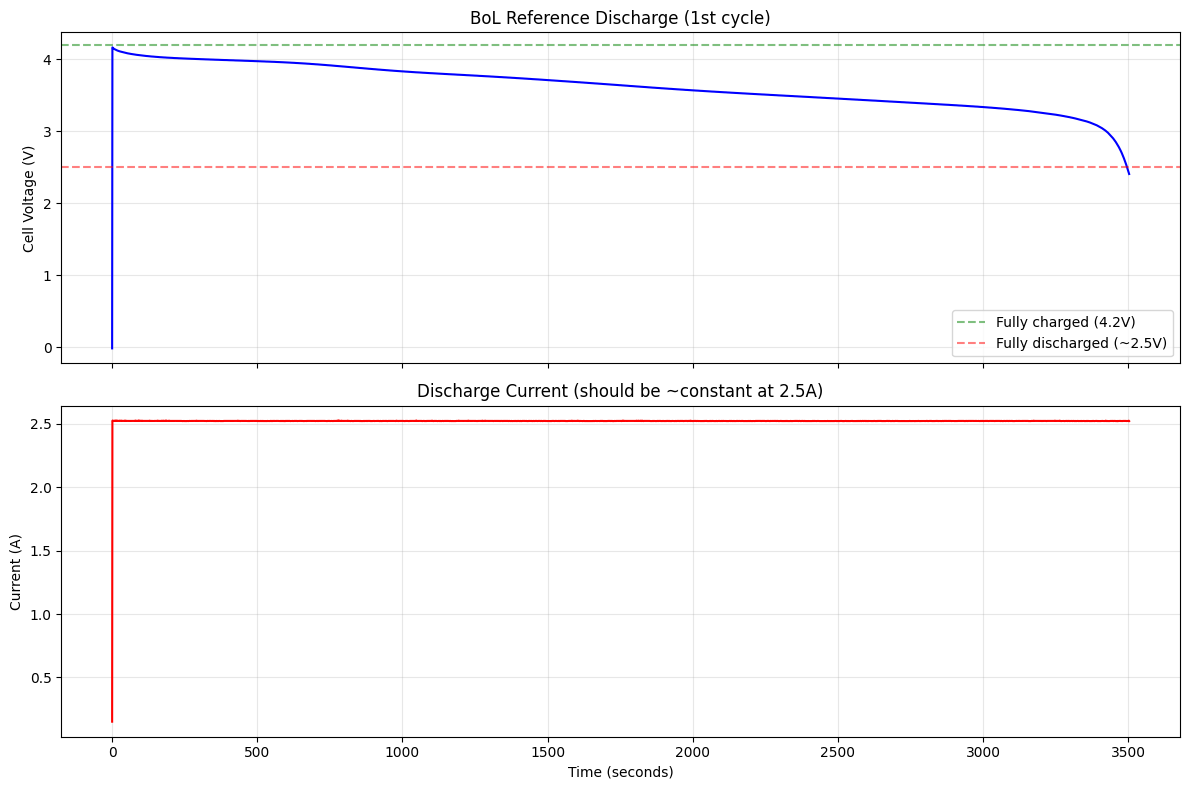

In [10]:
# Plot: BoL Discharge - Voltage and Current
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top: Voltage
ax1.plot(bol['time_relative'], bol['voltage_per_cell'], 'b-', linewidth=1.5)
ax1.set_ylabel('Cell Voltage (V)')
ax1.set_title('BoL Reference Discharge (1st cycle)')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=4.2, color='green', linestyle='--', alpha=0.5, label='Fully charged (4.2V)')
ax1.axhline(y=2.5, color='red', linestyle='--', alpha=0.5, label='Fully discharged (~2.5V)')
ax1.legend()

# Bottom: Current
ax2.plot(bol['time_relative'], bol['current_load'], 'r-', linewidth=1.5)
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Current (A)')
ax2.set_title('Discharge Current (should be ~constant at 2.5A)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 1.8 Summary — What We Know Now

After exploring the data:

1. **Dataset:** 1.1 million rows, 10 columns, ~300 hours of battery testing
2. **Our battery:** 2 cells in series (pack voltage ~8.4V → per-cell ~4.2V)
3. **9 reference discharge cycles** at constant ~2.5A current
4. **BoL capacity:** ~2.45 Ah
5. **Voltage range per cell:** ~4.17V (full) → ~2.40V (empty)

**What we'll use going forward:**
- The **1st reference discharge cycle** (BoL = Beginning of Life)
- Per-cell voltage (pack ÷ 2) and current data
- Capacity = ~2.45 Ah

---

**Next Step:** Build `data_loader.py` — a reusable module that extracts this BoL discharge data automatically so we don't repeat this filtering every time.